In [18]:
#Importuri
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline

In [19]:
#Incarcare de date
df = pd.read_csv("bodyPerformance.csv")
print("Shape:", df.shape)
df.head()

Shape: (13393, 12)


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [20]:
df.info()
# elimină spații din nume coloane (dacă există)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("\nColoane:", df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB

Coloane: ['age', 'gender', 'height_cm', 'weight_kg', 'body_fat_%', 'diastolic', '

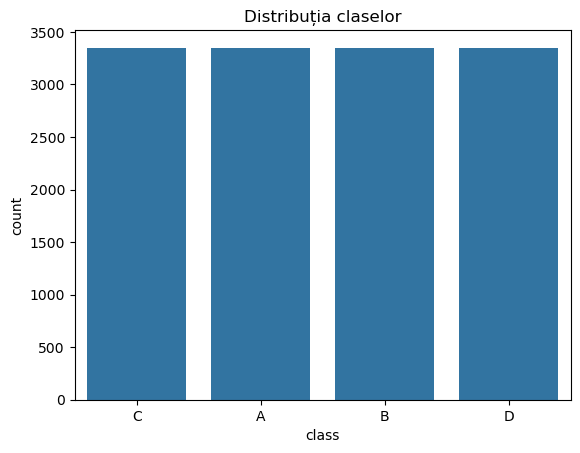

In [21]:
plt.figure()
sns.countplot(x="class", data=df)
plt.title("Distribuția claselor")
plt.show()

In [22]:
# gender → numeric
df["gender"] = LabelEncoder().fit_transform(df["gender"])
# target → numeric
df["class"] = LabelEncoder().fit_transform(df["class"])
df.head()

,age,gender,height_cm,weight_kg,body_fat_%,diastolic,systolic,gripforce,sit_and_bend_forward_cm,sit-ups_counts,broad_jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,1
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,1


In [23]:
#FEATURE VS TARGET
X = df.drop("class", axis=1)
y = df["class"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13393, 11)
y shape: (13393,)


In [24]:
#SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (10714, 11)
Test: (2679, 11)


In [29]:
#SCALARE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
#DECISION TREE
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5961179544606197


In [30]:
#KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [31]:

# COMPARAȚIE MODELE
from sklearn.metrics import accuracy_score
# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("Decision Tree Accuracy:", acc_dt)
print("KNN Accuracy:", acc_knn)

Decision Tree Accuracy: 0.5961179544606197
KNN Accuracy: 0.6080627099664053


In [32]:
#TABEL COMPARATIV
import pandas as pd
df_compare = pd.DataFrame({
    "Model": ["Decision Tree", "KNN"],
    "Accuracy": [acc_dt, acc_knn]
})
df_compare

,Model,Accuracy
0,Decision Tree,0.596118
1,KNN,0.608063


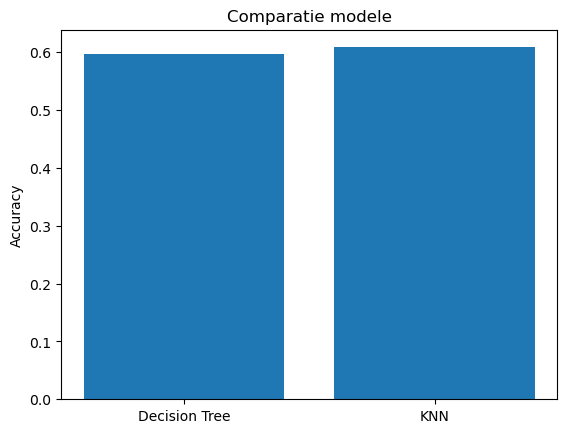

In [34]:
#GRAFIC
plt.figure()

plt.bar(df_compare["Model"], df_compare["Accuracy"])

plt.title("Comparatie modele")
plt.ylabel("Accuracy")

plt.show()

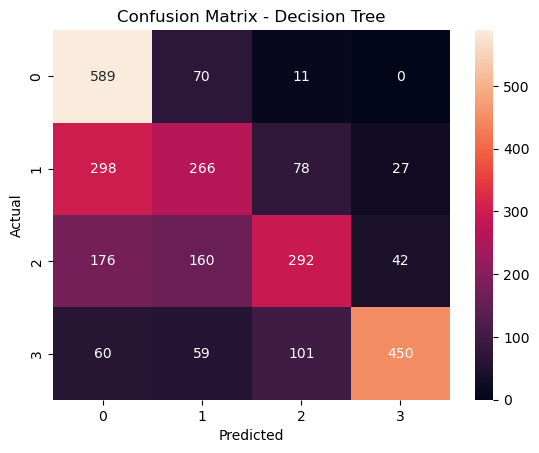

In [35]:
#CONFUSION MATRIX DT
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

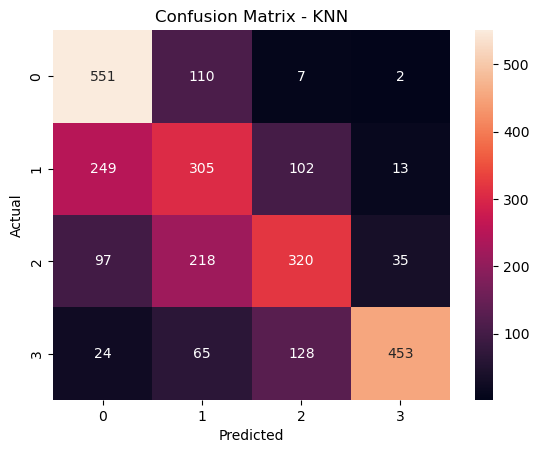

In [36]:
#CONFUSION MATRIX KNN
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

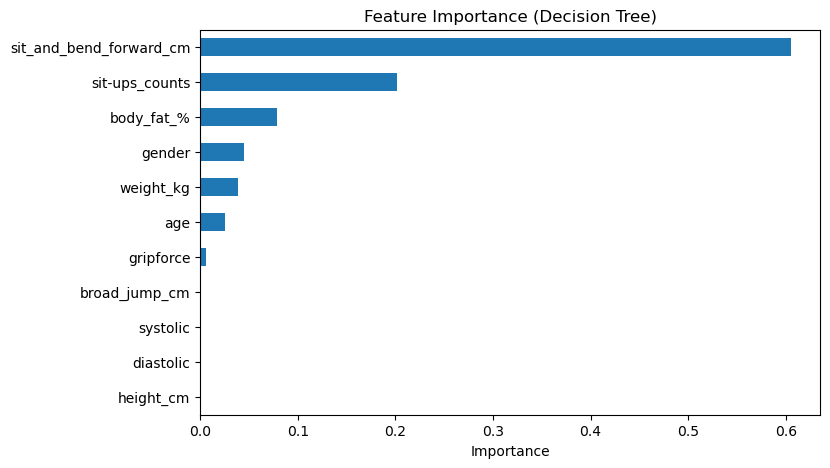

In [37]:
import pandas as pd
importance = pd.Series(dt.feature_importances_, index=X.columns)
importance = importance.sort_values()
plt.figure(figsize=(8,5))
importance.plot(kind="barh")
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.show()

Accuracy: 0.55


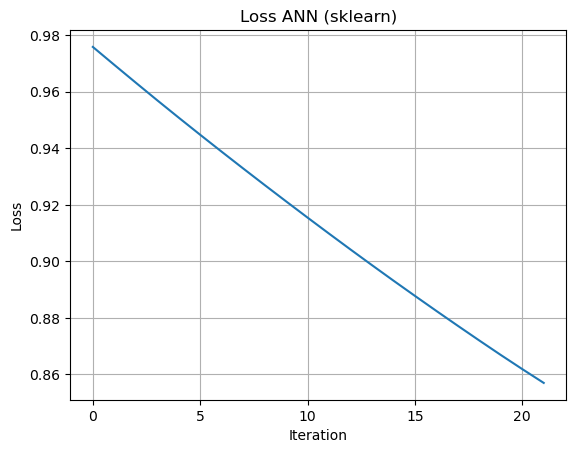

Predictions: [0 0]


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier


class DataProcessor:
    def __init__(self, df, target_column):
        self.df = df
        self.target_column = target_column
        self.scaler = StandardScaler()

    def preprocess(self):
        X = self.df.drop(self.target_column, axis=1)
        y = self.df[self.target_column]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        X_train = self.scaler.fit_transform(X_train)
        X_test = self.scaler.transform(X_test)

        return X_train, X_test, y_train, y_test


class ANNModel:
    def __init__(self, input_dim):
        self.model = MLPClassifier(
            hidden_layer_sizes=(16, 8),
            activation='relu',
            solver='adam',
            max_iter=1000,
            learning_rate_init=0.001,
            early_stopping=True,
            n_iter_no_change=20,
            random_state=42
        )

    def get_model(self):
        return self.model


class Trainer:
    def __init__(self, model):
        self.model = model

    def train(self, X_train, y_train):
        self.model.fit(X_train, y_train)

        history = {
            "loss": self.model.loss_curve_
        }

        return history


class Evaluator:
    def __init__(self, model):
        self.model = model

    def evaluate(self, X_test, y_test):
        y_pred = self.model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        return acc

    def test_custom_df(self, df, scaler):
        X = scaler.transform(df)
        preds = self.model.predict(X)
        return preds


class Visualizer:
    @staticmethod
    def plot_loss(history):
        plt.figure()
        plt.plot(history["loss"])
        plt.title("Loss ANN (sklearn)")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.grid()
        plt.show()


np.random.seed(42)

df = pd.DataFrame({
    "feature1": np.random.rand(200),
    "feature2": np.random.rand(200),
    "feature3": np.random.rand(200),
    "target": np.random.randint(0, 2, 200)
})

processor = DataProcessor(df, "target")
X_train, X_test, y_train, y_test = processor.preprocess()

model_wrapper = ANNModel(input_dim=X_train.shape[1])
model = model_wrapper.get_model()

trainer = Trainer(model)
history = trainer.train(X_train, y_train)

evaluator = Evaluator(model)
accuracy = evaluator.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

Visualizer.plot_loss(history)

df_new = pd.DataFrame({
    "feature1": [0.1, 0.9],
    "feature2": [0.2, 0.8],
    "feature3": [0.3, 0.7]
})

preds = evaluator.test_custom_df(df_new, processor.scaler)
print("Predictions:", preds)